In [49]:
#!pip install scikit-learn-extra
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import sklearn_extra
print(sklearn_extra.__version__)
from sklearn_extra.cluster import KMedoids

from sklearn.metrics import silhouette_score, adjusted_rand_score

0.3.0


In [50]:
# Load the Iris dataset
data = load_iris()
X, y = data.data, data.target
# Convert to DataFrame for easier manipulation (optional)
df = pd.DataFrame(data=np.c_[X, y],
columns=data.feature_names + ['target'])
# Explore the dataset
print(df.head())
print(df.describe())
print(df.info())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0     0.0  
1     0.0  
2     0.0  
3     0.0  
4     0.0  
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000  

In [51]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [52]:
# Initialize the K-means clustering algorithm with a specific k
kmeans = KMeans(n_clusters=3, random_state=42)
# Fit the model to the data
kmeans.fit(X_scaled)
# Get the cluster assignments for each sample
kmeans_labels = kmeans.labels_
# Calculate the silhouette score
kmeans_silhouette_score = silhouette_score(X_scaled, kmeans_labels)
# Calculate the adjusted Rand Index (ARI) score
kmeans_ari_score = adjusted_rand_score(y, kmeans_labels)
print(f"K-means Clustering:")
print(f"Silhouette Score: {kmeans_silhouette_score:.4f}")
print(f"Adjusted Rand Index Score: {kmeans_ari_score:.4f}")

K-means Clustering:
Silhouette Score: 0.4799
Adjusted Rand Index Score: 0.4328


In [53]:
# Initialize the K-medoids clustering algorithm with a specific k
kmedoids = KMedoids(n_clusters=3, random_state=42)
# Fit the model to the data
kmedoids.fit(X_scaled)
# Get the cluster assignments for each sample
kmedoids_labels = kmedoids.labels_
# Calculate the silhouette score
kmedoids_silhouette_score = silhouette_score(X_scaled, kmedoids_labels)
# Calculate the adjusted Rand Index (ARI) score
kmedoids_ari_score = adjusted_rand_score(y, kmedoids_labels)
print(f"\nK-medoids Clustering:")
print(f"Silhouette Score: {kmedoids_silhouette_score:.4f}")
print(f"Adjusted Rand Index Score: {kmedoids_ari_score:.4f}")


K-medoids Clustering:
Silhouette Score: 0.4590
Adjusted Rand Index Score: 0.6312


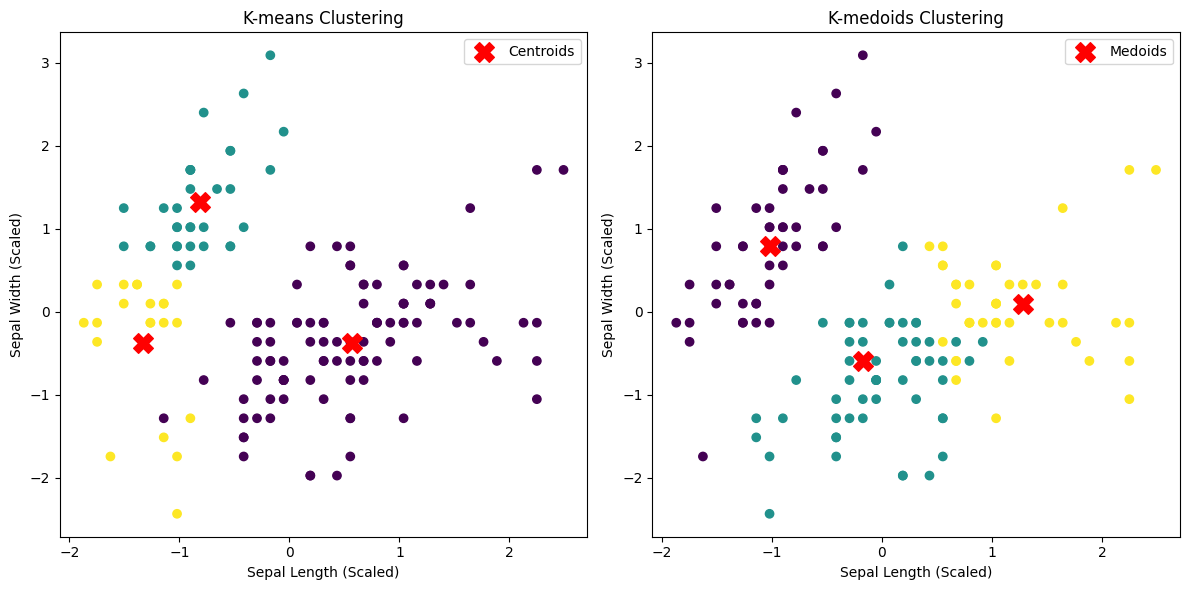

In [54]:
# Visualization of K-means and K-medoids Clusters
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1]
,marker='X', s=200, c='red',label='Centroids')
plt.title('K-means Clustering')
plt.xlabel('Sepal Length (Scaled)')
plt.ylabel('Sepal Width (Scaled)')
plt.legend()
plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmedoids_labels, cmap='viridis')
plt.scatter(kmedoids.cluster_centers_[:, 0], kmedoids.cluster_centers_[:, 1]
, marker='X', s=200, c='red', label='Medoids')
plt.title('K-medoids Clustering')
plt.xlabel('Sepal Length (Scaled)')
plt.ylabel('Sepal Width (Scaled)')
plt.legend()
plt.tight_layout()
plt.show()

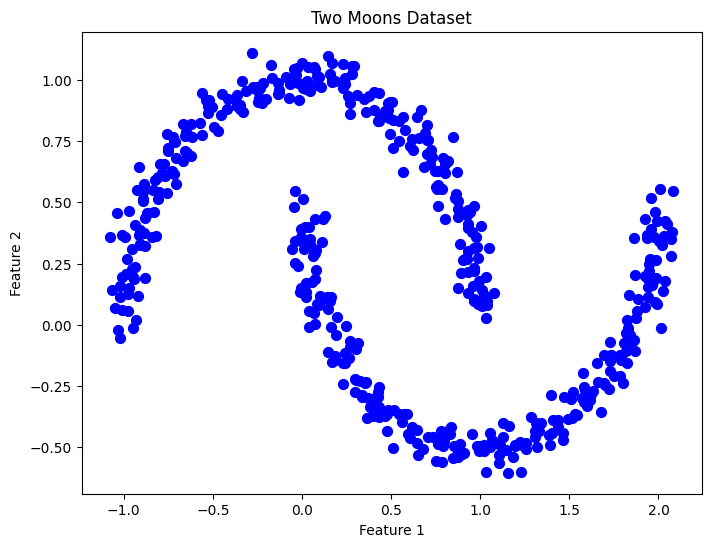

In [55]:
from sklearn.datasets import make_moons
# Generate the "Two Moons" dataset
X, y = make_moons(n_samples=500, noise=0.05, random_state=42)
# Plot the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c='b', s=50)
plt.title("Two Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

STING Clustering:
Adjusted Rand Index Score: 0.2816


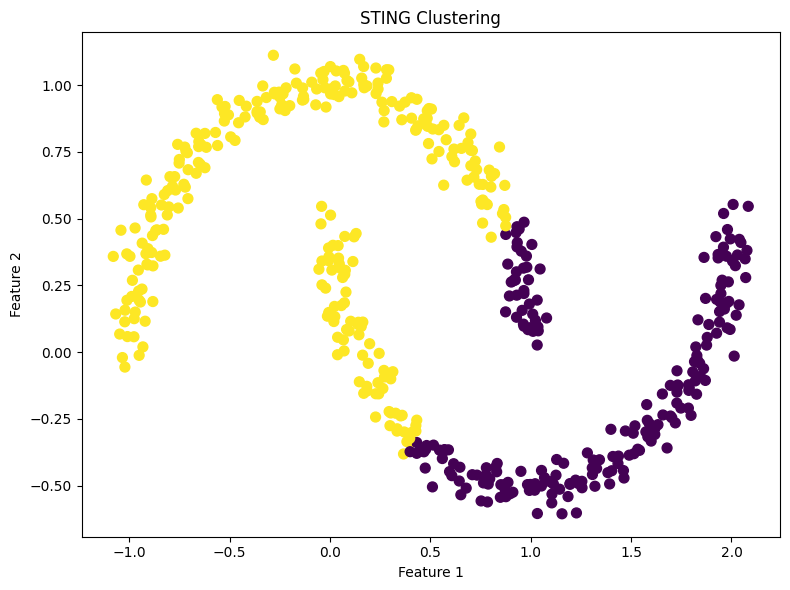

In [56]:
#from sklearn_extra.cluster import KMedoids
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score
# Perform STING clustering
grid_size = 2
sting = KMedoids(n_clusters=2, random_state=42)
sting_labels = sting.fit_predict(X)
# Calculate the Adjusted Rand Index (ARI) score
ari_score_sting = adjusted_rand_score(y, sting_labels)
print(f"STING Clustering:")
print(f"Adjusted Rand Index Score: {ari_score_sting:.4f}")


# Visualization of Clustering Results
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=sting_labels, cmap='viridis', s=50)
plt.title('STING Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.tight_layout()
plt.show()

OPTICS Clustering:
Adjusted Rand Index Score: 1.0000


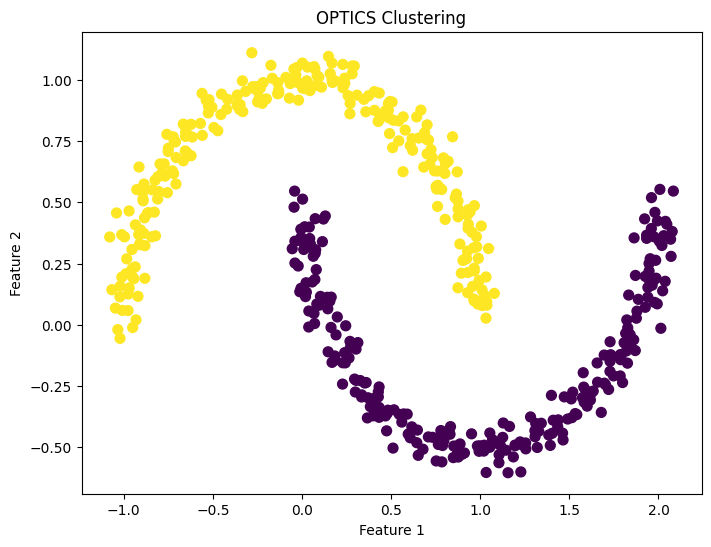

In [57]:
from sklearn.cluster import OPTICS
from sklearn.metrics import adjusted_rand_score
# Perform OPTICS clustering
optics = OPTICS(min_samples=10, xi=0.15, min_cluster_size=0.15)
optics_labels = optics.fit_predict(X)
# Calculate the Adjusted Rand Index (ARI) score
ari_score_optics = adjusted_rand_score(y, optics_labels)
print(f"OPTICS Clustering:")
print(f"Adjusted Rand Index Score: {ari_score_optics:.4f}")

# Visualization of OPTICS Clustering Results
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=optics_labels, cmap='viridis', s=50)
plt.title('OPTICS Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

DBSCAN Clustering:
Adjusted Rand Index Score: 1.0000


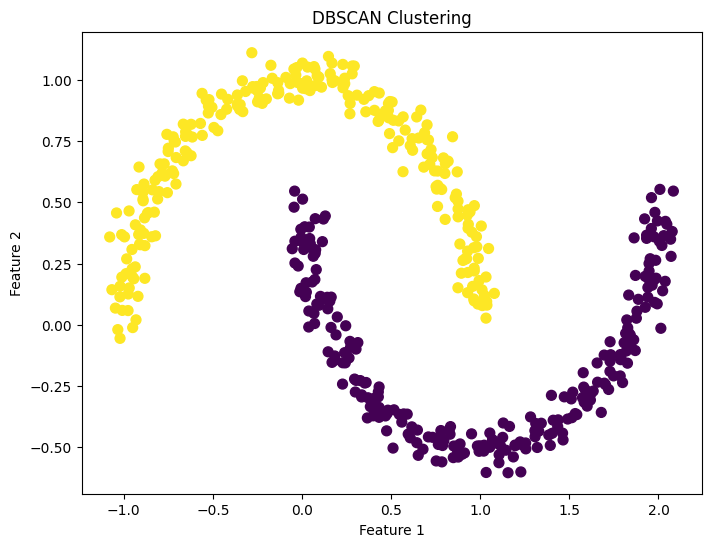

In [58]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score
# Perform DBSCAN clustering
dbscan = DBSCAN(eps=0.15, min_samples=10)
dbscan_labels = dbscan.fit_predict(X)
# Calculate the Adjusted Rand Index (ARI) score
ari_score_dbscan = adjusted_rand_score(y, dbscan_labels)
print(f"DBSCAN Clustering:")
print(f"Adjusted Rand Index Score: {ari_score_dbscan:.4f}")

# Visualization of DBSCAN Clustering Results
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=dbscan_labels, cmap='viridis', s=50)
plt.title('DBSCAN Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [59]:
##Load dataset and preprocess it
from sklearn.datasets import load_digits
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
dataset = load_digits()
dataset.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [60]:
dataset.data.shape

(1797, 64)

In [61]:
dataset.data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [62]:
dataset.data[0].reshape(8,8)

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

<Figure size 640x480 with 0 Axes>

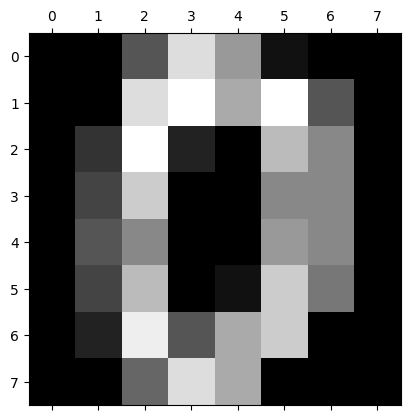

In [63]:
plt.gray()
plt.matshow(dataset.data[0].reshape(8,8))

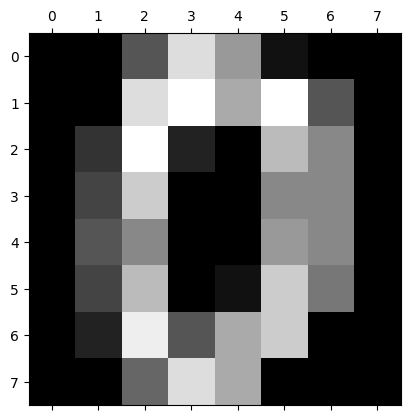

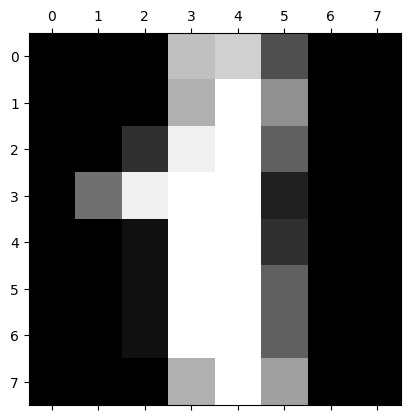

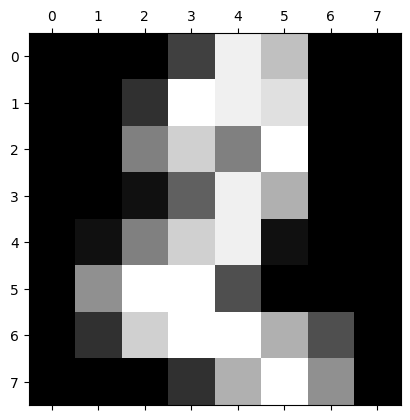

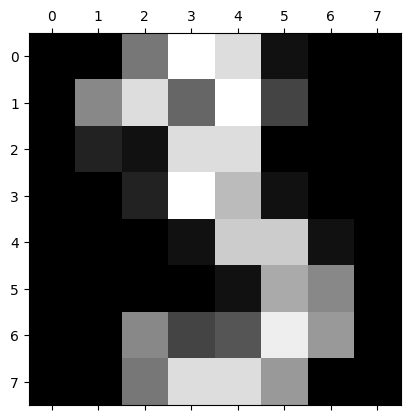

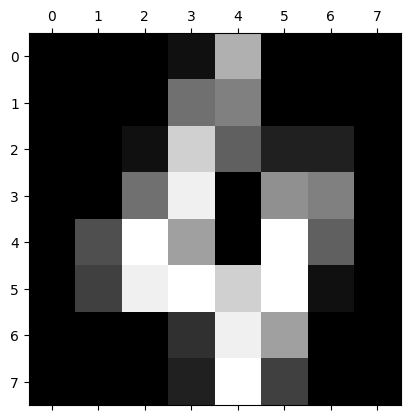

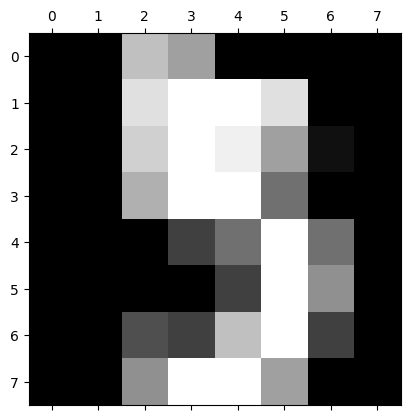

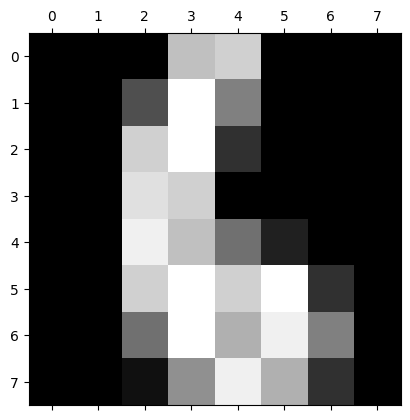

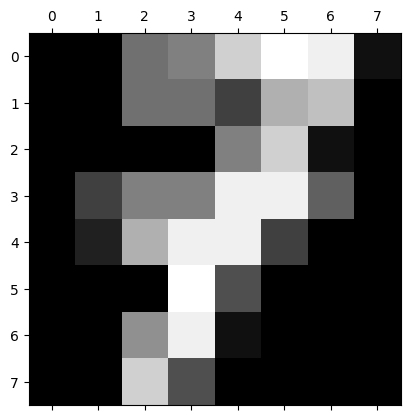

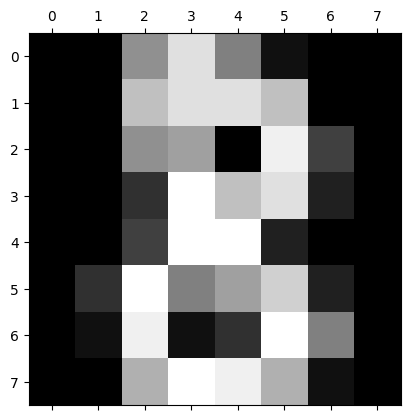

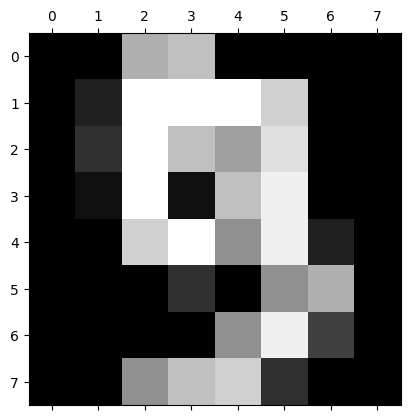

In [64]:
for i in range(10):
    plt.matshow(dataset.data[i].reshape(8,8))

In [65]:
dataset.target

array([0, 1, 2, ..., 8, 9, 8])

In [66]:
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [67]:
df.describe()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,...,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,3.725097,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,4.919406,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,11.000000,10.000000,0.000000,0.000000,0.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,4.000000,13.000000,14.000000,6.000000,0.000000,0.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,11.000000,0.000000,0.000000,0.000000,3.000000,...,7.000000,0.000000,0.000000,0.000000,10.000000,16.000000,16.000000,12.000000,2.000000,0.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,16.000000,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000


In [68]:
X = df
y = dataset.target
scaler = StandardScaler()
X = scaler.fit_transform(X)
X

array([[ 0.        , -0.33501649, -0.04308102, ..., -1.14664746,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  0.54856067,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  1.56568555,
         1.6951369 , -0.19600752],
       ...,
       [ 0.        , -0.33501649, -0.88456568, ..., -0.12952258,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -0.67419451, ...,  0.8876023 ,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649,  1.00877481, ...,  0.8876023 ,
        -0.26113572, -0.19600752]])

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.9722222222222222

95% 32 features

In [70]:
from sklearn.decomposition import PCA
dataset = load_digits()

X = dataset.data
y = dataset.target

pca = PCA(n_components=32, random_state=42)
X_32 = pca.fit_transform(X)
X_32.shape


(1797, 32)

In [71]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.9666666666666667

In [84]:
from sklearn.decomposition import PCA
dataset = load_digits()

X = dataset.data
y = dataset.target

pca = PCA(n_components=24, random_state=42)
X_32 = pca.fit_transform(X)
X_32.shape


X_train, X_test, y_train, y_test = train_test_split(X_32, y, test_size=0.2, random_state=30)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
model.score(X_test, y_test)


0.9638888888888889

In [75]:
dataset = load_digits()

X = dataset.data
y = dataset.target

# 1️⃣ Scale first
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 2️⃣ PCA with variance threshold
pca = PCA(n_components=0.95)   # ← change to 0.90 for 90%
X = pca.fit_transform(X)

# 3️⃣ Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=30
)

# 4️⃣ Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.9638888888888889